# DWTS 淘汰周规律性分析

**目标**: 探索 Dancing with the Stars 数据中「单淘汰周 vs 多淘汰周 vs 不淘汰周」的规律性。

**分析内容**:
1. 数据读取与清洗
2. 构造 week-level 聚合表
3. 可视化分析
4. 统计检验
5. 序列模式分析（Markov 转移矩阵）
6. 可解释预测模型

---
## Section 1: 数据读取与清洗

**问题**: 原始数据包含多行（每行=选手-周），需要过滤并检查数据质量。

**方法**:
- 仅保留 `week_exists == 1` 的记录
- 将 `week_start`, `week_end` 转为 datetime（容错处理）
- 检查关键字段缺失与类型

**输出**: 清洗后的 DataFrame `df`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DATA_PATH = '../processed_with_trends_and_awards.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"原始数据形状: {df_raw.shape}")
print(f"列名: {df_raw.columns.tolist()[:15]}...")

原始数据形状: (4611, 43)
列名: ['season', 'week', 'week_exists', 'season_len', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry_region', 'celebrity_age_during_season', 'results', 'placement', 'judge_n', 'n_alive_w', 'performed']...


In [2]:
# 1.1 过滤 week_exists == 1
if df_raw['week_exists'].dtype == 'object':
    df = df_raw[df_raw['week_exists'].astype(str).str.lower() == 'true'].copy()
else:
    df = df_raw[df_raw['week_exists'] == 1].copy()

print(f"过滤后数据形状: {df.shape}")
print(f"保留比例: {len(df)/len(df_raw)*100:.1f}%")

过滤后数据形状: (4180, 43)
保留比例: 90.7%


In [3]:
# 1.2 转换日期字段（容错处理）
for col in ['week_start', 'week_end']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    n_invalid = df[col].isna().sum()
    print(f"{col}: {n_invalid} 个无效日期 ({n_invalid/len(df)*100:.2f}%)")

week_start: 0 个无效日期 (0.00%)
week_end: 0 个无效日期 (0.00%)


In [4]:
# 1.3 检查关键字段缺失与类型
key_cols = ['season', 'week', 'eliminated_end_of_week', 'n_alive_w', 'season_len', 'num_episodes']

print("关键字段检查:")
print("-" * 50)
for col in key_cols:
    if col in df.columns:
        n_missing = df[col].isna().sum()
        dtype = df[col].dtype
        print(f"{col:25s} | 类型: {str(dtype):10s} | 缺失: {n_missing:5d} ({n_missing/len(df)*100:.2f}%)")
    else:
        print(f"{col:25s} | *** 字段不存在 ***")

关键字段检查:
--------------------------------------------------
season                    | 类型: float64    | 缺失:     0 (0.00%)
week                      | 类型: float64    | 缺失:     0 (0.00%)
eliminated_end_of_week    | 类型: object     | 缺失:     0 (0.00%)
n_alive_w                 | 类型: float64    | 缺失:     0 (0.00%)
season_len                | 类型: float64    | 缺失:     0 (0.00%)
num_episodes              | 类型: float64    | 缺失:     0 (0.00%)


In [5]:
# 1.4 确保关键字段类型正确
df['season'] = df['season'].astype(int)
df['week'] = df['week'].astype(int)
df['season_len'] = df['season_len'].astype(int)
df['n_alive_w'] = df['n_alive_w'].astype(int)
df['num_episodes'] = df['num_episodes'].astype(float)

if df['eliminated_end_of_week'].dtype == 'object':
    df['eliminated_end_of_week'] = df['eliminated_end_of_week'].astype(str).str.lower() == 'true'
df['eliminated_end_of_week'] = df['eliminated_end_of_week'].astype(int)

print("类型转换完成")
df[key_cols].dtypes

类型转换完成


season                      int64
week                        int64
eliminated_end_of_week      int64
n_alive_w                   int64
season_len                  int64
num_episodes              float64
dtype: object

In [6]:
# 1.5 数据概览
print(f"Seasons: {df['season'].nunique()} (范围: {df['season'].min()} - {df['season'].max()})")
print(f"总记录数: {len(df)}")
print(f"\n前5行:")
df[['season', 'week', 'celebrity_name', 'eliminated_end_of_week', 'n_alive_w', 'season_len', 'num_episodes']].head()

Seasons: 34 (范围: 1 - 34)
总记录数: 4180

前5行:


,season,week,celebrity_name,eliminated_end_of_week,n_alive_w,season_len,num_episodes
0,29,1,AJ McLean,0,15,11,1.0
1,29,2,AJ McLean,0,15,11,1.0
2,29,3,AJ McLean,0,14,11,1.0
3,29,4,AJ McLean,0,13,11,1.0
4,29,5,AJ McLean,0,12,11,1.0


---
## Section 2: 构造 Week-Level 表 `week_df`

**问题**: 原始数据是选手-周级别，需要聚合为周级别（一行 = 一个 season-week）。

**方法**:
- 按 `(season, week)` 聚合计算 `n_elim`, `n_alive`, `season_len`, `num_episodes`
- 定义 `elim_type`: none (0淘汰), single (1淘汰), multi (≥2淘汰)
- 计算衍生特征: `week_rel`, `remaining_weeks`, `need_elims`, `schedule_pressure`
- 计算 `prev_elim_type`（前一周的淘汰类型）

**输出**: `week_df` 表

In [7]:
# 2.1 按 (season, week) 聚合
week_df = df.groupby(['season', 'week']).agg({
    'eliminated_end_of_week': 'sum',
    'n_alive_w': 'max',
    'season_len': 'max',
    'num_episodes': 'max',
    'week_start': 'max',
    'week_end': 'max'
}).reset_index()

week_df.columns = ['season', 'week', 'n_elim', 'n_alive', 'season_len', 'num_episodes', 'week_start', 'week_end']
print(f"week_df 形状: {week_df.shape}")
week_df.head(10)

week_df 形状: (335, 8)


,season,week,n_elim,n_alive,season_len,num_episodes,week_start,week_end
0,1,1,0,6,6,1.0,2005-06-01,2005-06-07
1,1,2,1,6,6,1.0,2005-06-08,2005-06-14
2,1,3,1,5,6,1.0,2005-06-15,2005-06-21
3,1,4,1,4,6,1.0,2005-06-22,2005-06-28
4,1,5,1,3,6,1.0,2005-06-29,2005-07-05
5,1,6,0,2,6,1.0,2005-07-06,2005-07-06
6,2,1,1,10,8,2.0,2006-01-05,2006-01-11
7,2,2,1,9,8,2.0,2006-01-12,2006-01-18
8,2,3,1,8,8,2.0,2006-01-19,2006-01-25
9,2,4,1,7,8,2.0,2006-01-26,2006-02-01


In [8]:
# 2.2 定义 elim_type
def get_elim_type(n):
    if n == 0:
        return 'none'
    elif n == 1:
        return 'single'
    else:
        return 'multi'

week_df['elim_type'] = week_df['n_elim'].apply(get_elim_type)

print("elim_type 分布:")
print(week_df['elim_type'].value_counts())

elim_type 分布:
elim_type
single    219
none       76
multi      40
Name: count, dtype: int64


In [9]:
# 2.3 计算每个 season 的 end_week 和 end_n
end_n_df = week_df.loc[week_df.groupby('season')['week'].idxmax()][['season', 'n_alive']]
end_n_df.columns = ['season', 'end_n']
season_end = week_df.groupby('season')['week'].max().reset_index()
season_end.columns = ['season', 'end_week']
season_end = season_end.merge(end_n_df, on='season')

week_df = week_df.merge(season_end, on='season')
print("Season 结束信息:")
season_end.head()

Season 结束信息:


,season,end_week,end_n
0,1,6,2
1,2,8,3
2,3,10,2
3,4,10,3
4,5,10,3


In [10]:
# 2.4 计算衍生特征
week_df['week_rel'] = week_df['week'] / week_df['season_len']
week_df['remaining_weeks'] = week_df['end_week'] - week_df['week']
week_df['need_elims'] = week_df['n_alive'] - week_df['end_n']
week_df['schedule_pressure'] = week_df['need_elims'] - week_df['remaining_weeks']

print("衍生特征统计:")
week_df[['week_rel', 'remaining_weeks', 'need_elims', 'schedule_pressure']].describe()

衍生特征统计:


,week_rel,remaining_weeks,need_elims,schedule_pressure
count,335.000000,335.000000,335.000000,335.000000
mean,0.550746,4.525373,4.779104,0.253731
std,0.287728,2.957551,3.094158,0.987092
min,0.090909,0.000000,0.000000,-2.000000
25%,0.300000,2.000000,2.000000,0.000000
50%,0.545455,4.000000,5.000000,0.000000
75%,0.800000,7.000000,7.000000,1.000000
max,1.000000,10.000000,13.000000,4.000000


In [11]:
# 2.5 计算 prev_elim_type
week_df = week_df.sort_values(['season', 'week'])
week_df['prev_elim_type'] = week_df.groupby('season')['elim_type'].shift(1)
week_df['prev_elim_type'] = week_df['prev_elim_type'].fillna('start')

print("prev_elim_type 分布:")
print(week_df['prev_elim_type'].value_counts())

prev_elim_type 分布:
prev_elim_type
single    219
none       42
multi      40
start      34
Name: count, dtype: int64


In [12]:
# 2.6 week_df 概览
print("week_df 基本信息:")
print(f"形状: {week_df.shape}")
print(f"Seasons: {week_df['season'].nunique()}")
print(f"\n前10行:")
week_df.head(10)

week_df 基本信息:
形状: (335, 16)
Seasons: 34

前10行:


,season,week,n_elim,n_alive,season_len,num_episodes,week_start,week_end,elim_type,end_week,end_n,week_rel,remaining_weeks,need_elims,schedule_pressure,prev_elim_type
0,1,1,0,6,6,1.0,2005-06-01,2005-06-07,none,6,2,0.166667,5,4,-1,start
1,1,2,1,6,6,1.0,2005-06-08,2005-06-14,single,6,2,0.333333,4,4,0,none
2,1,3,1,5,6,1.0,2005-06-15,2005-06-21,single,6,2,0.500000,3,3,0,single
3,1,4,1,4,6,1.0,2005-06-22,2005-06-28,single,6,2,0.666667,2,2,0,single
4,1,5,1,3,6,1.0,2005-06-29,2005-07-05,single,6,2,0.833333,1,1,0,single
5,1,6,0,2,6,1.0,2005-07-06,2005-07-06,none,6,2,1.000000,0,0,0,single
6,2,1,1,10,8,2.0,2006-01-05,2006-01-11,single,8,3,0.125000,7,7,0,start
7,2,2,1,9,8,2.0,2006-01-12,2006-01-18,single,8,3,0.250000,6,6,0,single
8,2,3,1,8,8,2.0,2006-01-19,2006-01-25,single,8,3,0.375000,5,5,0,single
9,2,4,1,7,8,2.0,2006-01-26,2006-02-01,single,8,3,0.500000,4,4,0,single


In [13]:
# 2.7 week_df 统计描述
week_df.describe()

,season,week,n_elim,n_alive,season_len,num_episodes,week_start,week_end,end_week,end_n,week_rel,remaining_weeks,need_elims,schedule_pressure
count,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000,335,335,335.000000,335.000000,335.000000,335.000000,335.000000,335.000000
mean,17.722388,5.525373,0.898507,8.289552,10.050746,1.513433,2014-08-01 18:54:48.358209,2014-08-07 07:05:33.134328,10.050746,3.510448,0.550746,4.525373,4.779104,0.253731
min,1.000000,1.000000,0.000000,2.000000,4.000000,1.000000,2005-06-01 00:00:00,2005-06-07 00:00:00,4.000000,2.000000,0.090909,0.000000,0.000000,-2.000000
25%,9.000000,3.000000,1.000000,6.000000,10.000000,1.000000,2009-11-19 12:00:00,2009-11-23 00:00:00,10.000000,3.000000,0.300000,2.000000,2.000000,0.000000
50%,18.000000,5.000000,1.000000,8.000000,10.000000,1.000000,2014-03-24 00:00:00,2014-03-30 00:00:00,10.000000,3.000000,0.545455,4.000000,5.000000,0.000000
75%,26.000000,8.000000,1.000000,11.000000,11.000000,2.000000,2018-05-10 12:00:00,2018-05-16 12:00:00,11.000000,4.000000,0.800000,7.000000,7.000000,1.000000
max,34.000000,11.000000,3.000000,16.000000,11.000000,3.000000,2025-11-25 00:00:00,2025-11-25 00:00:00,11.000000,5.000000,1.000000,10.000000,13.000000,4.000000
std,9.670497,2.957551,0.595767,3.190045,1.078002,0.535253,NaN,NaN,1.078002,0.729435,0.287728,2.957551,3.094158,0.987092


---
## Section 3: 可视化分析

**问题**: 探索淘汰模式在不同维度上的分布规律。

**方法**:
1. Heatmap: season × week → n_elim
2. Stacked bar: elim_type 按 week 的计数与比例
3. Multi 概率随赛季进度 (week_rel) 的变化
4. schedule_pressure 在不同 elim_type 的分布
5. num_episodes > 1 与 multi 的关系

**输出**: 多张可视化图表

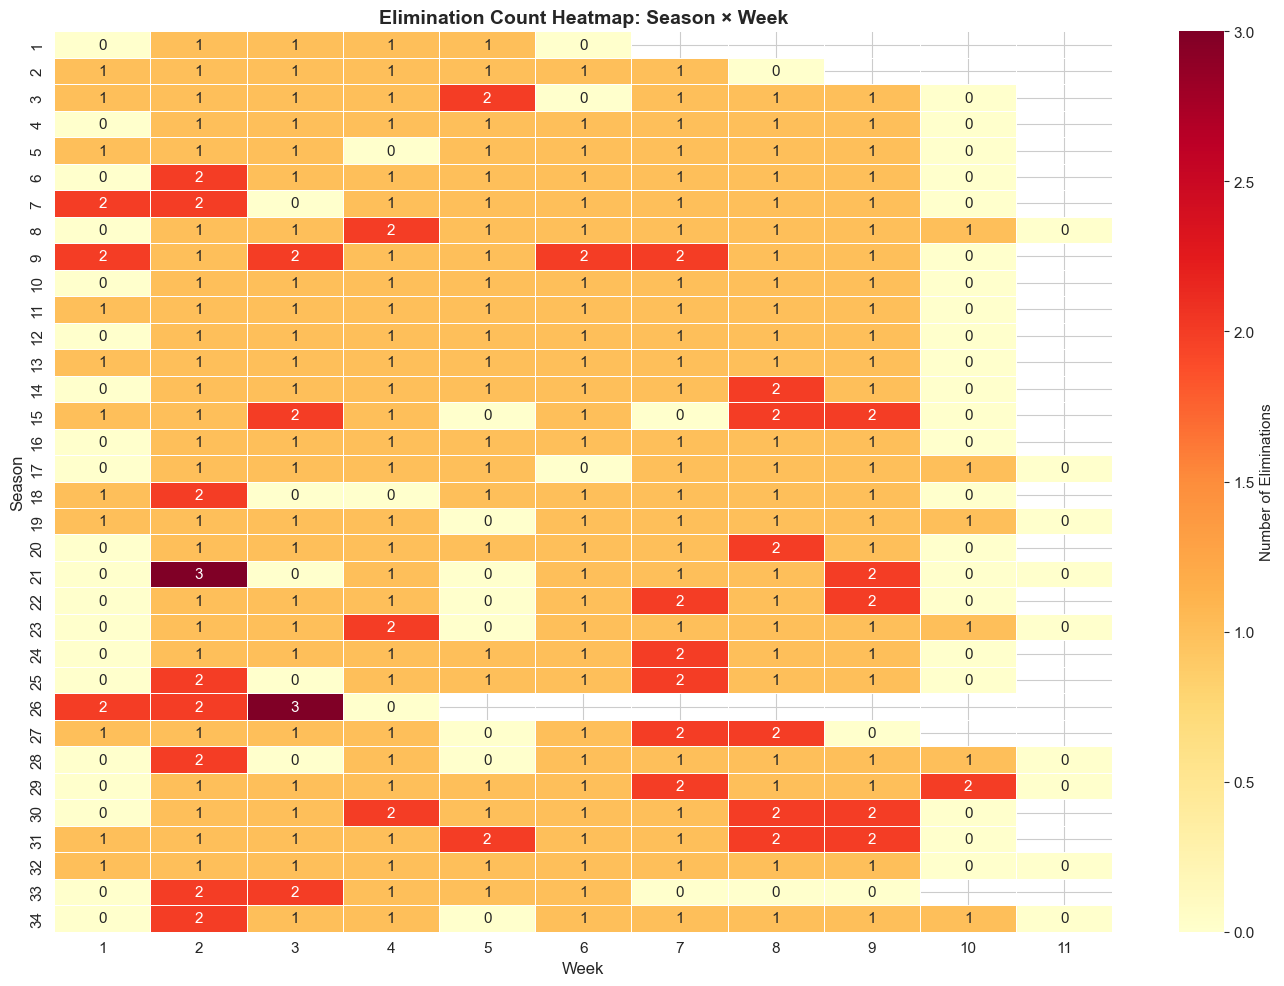

In [14]:
# 3.1 Heatmap: season × week → n_elim
pivot_elim = week_df.pivot(index='season', columns='week', values='n_elim')

plt.figure(figsize=(14, 10))
sns.heatmap(pivot_elim, cmap='YlOrRd', annot=True, fmt='.0f', 
            cbar_kws={'label': 'Number of Eliminations'},
            linewidths=0.5, linecolor='white')
plt.title('Elimination Count Heatmap: Season × Week', fontsize=14, fontweight='bold')
plt.xlabel('Week', fontsize=12)
plt.ylabel('Season', fontsize=12)
plt.tight_layout()
plt.savefig('heatmap_eliminations.png', dpi=150, bbox_inches='tight')
plt.show()

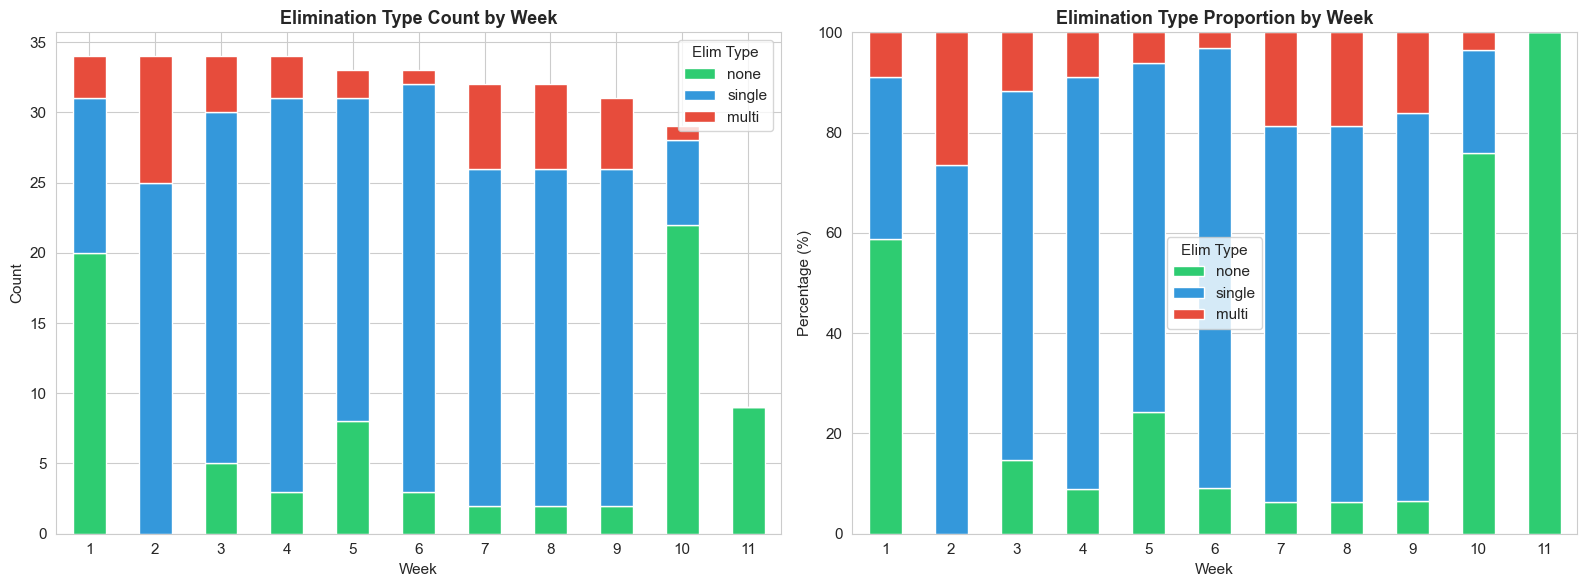

In [15]:
# 3.2 Stacked Bar: elim_type count by week
elim_by_week = week_df.groupby(['week', 'elim_type']).size().unstack(fill_value=0)
col_order = ['none', 'single', 'multi']
elim_by_week = elim_by_week.reindex(columns=[c for c in col_order if c in elim_by_week.columns])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

elim_by_week.plot(kind='bar', stacked=True, ax=axes[0], 
                  color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
axes[0].set_title('Elimination Type Count by Week', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Week', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(title='Elim Type')
axes[0].tick_params(axis='x', rotation=0)

elim_by_week_pct = elim_by_week.div(elim_by_week.sum(axis=1), axis=0) * 100
elim_by_week_pct.plot(kind='bar', stacked=True, ax=axes[1],
                      color=['#2ecc71', '#3498db', '#e74c3c'], edgecolor='white')
axes[1].set_title('Elimination Type Proportion by Week', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Week', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].legend(title='Elim Type')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('stacked_bar_elim_type.png', dpi=150, bbox_inches='tight')
plt.show()

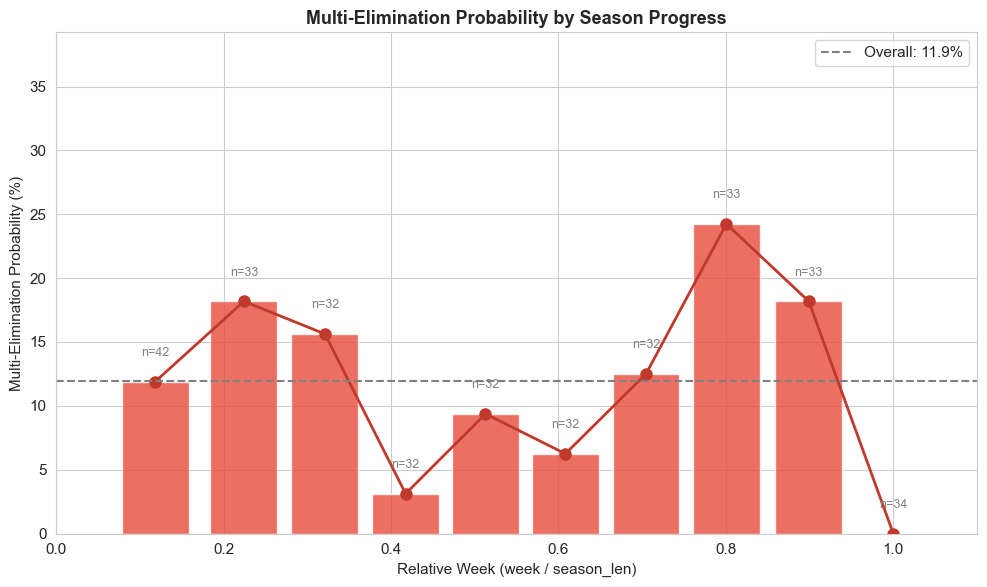

In [16]:
# 3.3 Multi 概率随 week_rel 变化
week_df['week_rel_bin'] = pd.cut(week_df['week_rel'], bins=10, labels=False)
week_df['is_multi'] = (week_df['elim_type'] == 'multi').astype(int)

multi_prob = week_df.groupby('week_rel_bin').agg({
    'is_multi': ['mean', 'sum', 'count'],
    'week_rel': 'mean'
}).reset_index()
multi_prob.columns = ['bin', 'multi_prob', 'multi_count', 'total_count', 'week_rel_mean']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(multi_prob['week_rel_mean'], multi_prob['multi_prob'] * 100, 
              width=0.08, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.plot(multi_prob['week_rel_mean'], multi_prob['multi_prob'] * 100, 
        'o-', color='#c0392b', linewidth=2, markersize=8)

for i, row in multi_prob.iterrows():
    ax.annotate(f'n={int(row["total_count"])}', 
                xy=(row['week_rel_mean'], row['multi_prob'] * 100 + 2),
                ha='center', fontsize=9, color='gray')

ax.set_title('Multi-Elimination Probability by Season Progress', fontsize=13, fontweight='bold')
ax.set_xlabel('Relative Week (week / season_len)', fontsize=11)
ax.set_ylabel('Multi-Elimination Probability (%)', fontsize=11)
ax.set_xlim(0, 1.1)
ax.set_ylim(0, max(multi_prob['multi_prob'] * 100) + 15)
ax.axhline(y=week_df['is_multi'].mean() * 100, color='gray', linestyle='--', 
           label=f'Overall: {week_df["is_multi"].mean()*100:.1f}%')
ax.legend()

plt.tight_layout()
plt.savefig('multi_prob_by_progress.png', dpi=150, bbox_inches='tight')
plt.show()

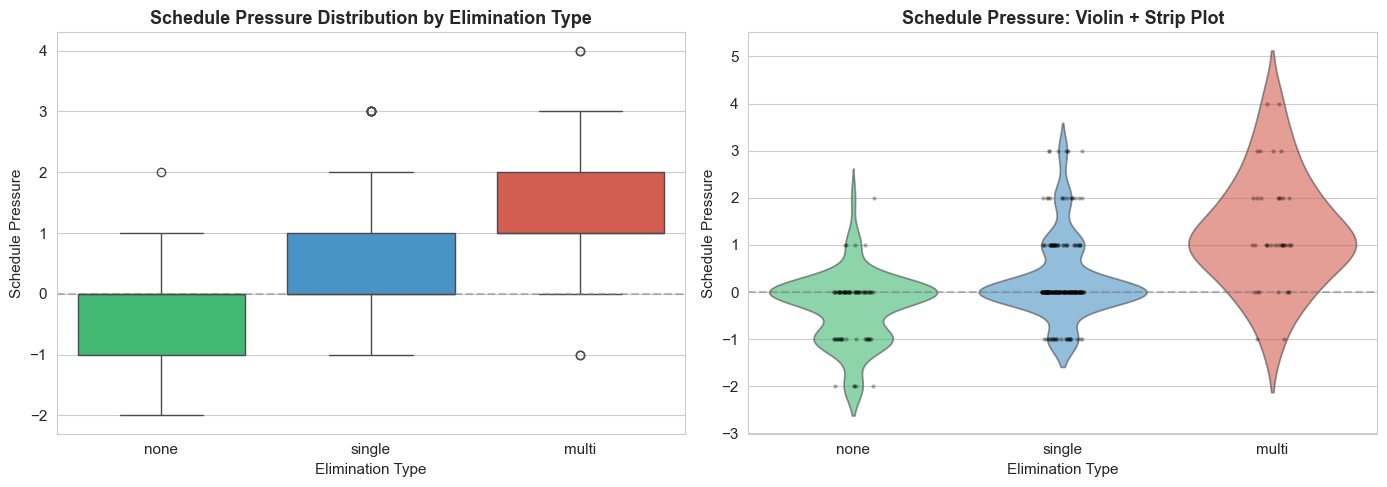

Schedule Pressure 统计 (按 elim_type):
           count      mean       std  min  25%  50%  75%  max
elim_type                                                    
multi       40.0  1.275000  1.176424 -1.0  1.0  1.0  2.0  4.0
none        76.0 -0.328947  0.737349 -2.0 -1.0  0.0  0.0  2.0
single     219.0  0.269406  0.864979 -1.0  0.0  0.0  1.0  3.0


In [17]:
# 3.4 Schedule Pressure 在不同 elim_type 的分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ['none', 'single', 'multi']
colors = {'none': '#2ecc71', 'single': '#3498db', 'multi': '#e74c3c'}
sns.boxplot(data=week_df, x='elim_type', y='schedule_pressure', order=order,
            palette=colors, ax=axes[0])
axes[0].set_title('Schedule Pressure Distribution by Elimination Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Elimination Type', fontsize=11)
axes[0].set_ylabel('Schedule Pressure', fontsize=11)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

sns.violinplot(data=week_df, x='elim_type', y='schedule_pressure', order=order,
               palette=colors, ax=axes[1], inner=None, alpha=0.6)
sns.stripplot(data=week_df, x='elim_type', y='schedule_pressure', order=order,
              color='black', alpha=0.3, size=3, ax=axes[1])
axes[1].set_title('Schedule Pressure: Violin + Strip Plot', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Elimination Type', fontsize=11)
axes[1].set_ylabel('Schedule Pressure', fontsize=11)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('schedule_pressure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Schedule Pressure 统计 (按 elim_type):")
print(week_df.groupby('elim_type')['schedule_pressure'].describe())

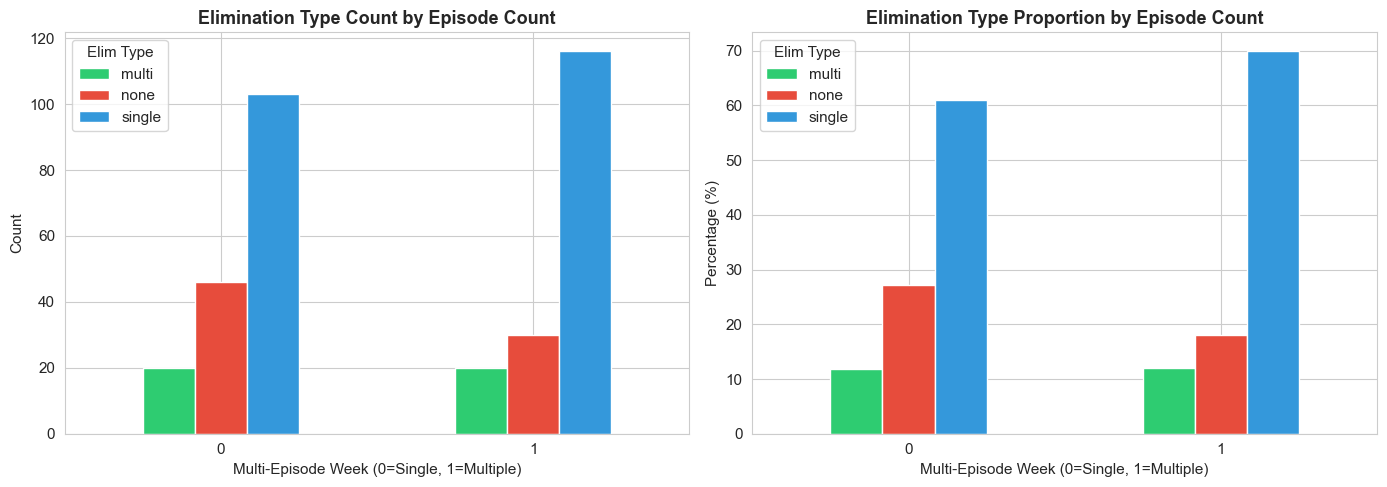


交叉表 (计数):
elim_type      multi  none  single
multi_episode                     
0                 20    46     103
1                 20    30     116

交叉表 (行百分比):
elim_type      multi  none  single
multi_episode                     
0               11.8  27.2    60.9
1               12.0  18.1    69.9


In [18]:
# 3.5 num_episodes > 1 与 multi 的关系
week_df['multi_episode'] = (week_df['num_episodes'] > 1).astype(int)

cross_tab = pd.crosstab(week_df['multi_episode'], week_df['elim_type'], 
                        normalize='index') * 100
cross_tab_count = pd.crosstab(week_df['multi_episode'], week_df['elim_type'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cross_tab_count.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'],
                     edgecolor='white')
axes[0].set_title('Elimination Type Count by Episode Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Multi-Episode Week (0=Single, 1=Multiple)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Elim Type')

cross_tab.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c', '#3498db'],
               edgecolor='white')
axes[1].set_title('Elimination Type Proportion by Episode Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Multi-Episode Week (0=Single, 1=Multiple)', fontsize=11)
axes[1].set_ylabel('Percentage (%)', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Elim Type')

plt.tight_layout()
plt.savefig('multi_episode_vs_elim.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n交叉表 (计数):")
print(cross_tab_count)
print("\n交叉表 (行百分比):")
print(cross_tab.round(1))

---
## Section 4: 统计检验

**问题**: 验证观察到的模式是否具有统计显著性。

**方法**:
1. 卡方检验: elim_type vs week / week_rel_bin
2. Mann-Whitney U 检验: multi vs non-multi 的 schedule_pressure
3. 计算效应量 (Cohen's d / rank-biserial correlation)

**输出**: 检验结果与效应量

In [19]:
# 4.1 卡方检验: elim_type vs week
contingency_week = pd.crosstab(week_df['week'], week_df['elim_type'])
chi2_week, p_week, dof_week, expected_week = stats.chi2_contingency(contingency_week)

print("="*60)
print("卡方检验: elim_type vs week")
print("="*60)
print(f"Chi-square statistic: {chi2_week:.4f}")
print(f"p-value: {p_week:.4e}")
print(f"Degrees of freedom: {dof_week}")
print(f"显著性: {'*** 显著 (p < 0.001)' if p_week < 0.001 else '** 显著 (p < 0.01)' if p_week < 0.01 else '* 显著 (p < 0.05)' if p_week < 0.05 else '不显著'}")

n = contingency_week.sum().sum()
min_dim = min(contingency_week.shape) - 1
cramers_v = np.sqrt(chi2_week / (n * min_dim))
print(f"Cramér's V (效应量): {cramers_v:.4f}")
print(f"效应量解释: {'小' if cramers_v < 0.1 else '中等' if cramers_v < 0.3 else '大'}")

卡方检验: elim_type vs week
Chi-square statistic: 147.2565
p-value: 2.1038e-21
Degrees of freedom: 20
显著性: *** 显著 (p < 0.001)
Cramér's V (效应量): 0.4688
效应量解释: 大


In [20]:
# 4.2 卡方检验: elim_type vs week_rel_bin
contingency_rel = pd.crosstab(week_df['week_rel_bin'], week_df['elim_type'])
chi2_rel, p_rel, dof_rel, expected_rel = stats.chi2_contingency(contingency_rel)

print("="*60)
print("卡方检验: elim_type vs week_rel_bin (相对进度)")
print("="*60)
print(f"Chi-square statistic: {chi2_rel:.4f}")
print(f"p-value: {p_rel:.4e}")
print(f"Degrees of freedom: {dof_rel}")
print(f"显著性: {'*** 显著 (p < 0.001)' if p_rel < 0.001 else '** 显著 (p < 0.01)' if p_rel < 0.01 else '* 显著 (p < 0.05)' if p_rel < 0.05 else '不显著'}")

n_rel = contingency_rel.sum().sum()
min_dim_rel = min(contingency_rel.shape) - 1
cramers_v_rel = np.sqrt(chi2_rel / (n_rel * min_dim_rel))
print(f"Cramér's V (效应量): {cramers_v_rel:.4f}")

卡方检验: elim_type vs week_rel_bin (相对进度)
Chi-square statistic: 175.1358
p-value: 8.7915e-28
Degrees of freedom: 18
显著性: *** 显著 (p < 0.001)
Cramér's V (效应量): 0.5113


In [21]:
# 4.3 Mann-Whitney U 检验: multi vs non-multi 的 schedule_pressure
multi_pressure = week_df[week_df['elim_type'] == 'multi']['schedule_pressure']
non_multi_pressure = week_df[week_df['elim_type'] != 'multi']['schedule_pressure']

u_stat, p_mw = stats.mannwhitneyu(multi_pressure, non_multi_pressure, alternative='two-sided')

print("="*60)
print("Mann-Whitney U 检验: schedule_pressure (multi vs non-multi)")
print("="*60)
print(f"Multi 组: n={len(multi_pressure)}, median={multi_pressure.median():.2f}, mean={multi_pressure.mean():.2f}")
print(f"Non-multi 组: n={len(non_multi_pressure)}, median={non_multi_pressure.median():.2f}, mean={non_multi_pressure.mean():.2f}")
print(f"\nU statistic: {u_stat:.4f}")
print(f"p-value: {p_mw:.4e}")
print(f"显著性: {'*** 显著 (p < 0.001)' if p_mw < 0.001 else '** 显著 (p < 0.01)' if p_mw < 0.01 else '* 显著 (p < 0.05)' if p_mw < 0.05 else '不显著'}")

n1, n2 = len(multi_pressure), len(non_multi_pressure)
r_rb = 1 - (2 * u_stat) / (n1 * n2)
print(f"\nRank-biserial correlation (效应量): {r_rb:.4f}")
print(f"效应量解释: {'小' if abs(r_rb) < 0.1 else '中等' if abs(r_rb) < 0.3 else '大'}")

Mann-Whitney U 检验: schedule_pressure (multi vs non-multi)
Multi 组: n=40, median=1.00, mean=1.27
Non-multi 组: n=295, median=0.00, mean=0.12

U statistic: 9363.0000
p-value: 2.1597e-11
显著性: *** 显著 (p < 0.001)

Rank-biserial correlation (效应量): -0.5869
效应量解释: 大


In [22]:
# 4.4 补充: t-test 与 Cohen's d
t_stat, p_t = stats.ttest_ind(multi_pressure, non_multi_pressure)

pooled_std = np.sqrt(((len(multi_pressure)-1)*multi_pressure.std()**2 + 
                      (len(non_multi_pressure)-1)*non_multi_pressure.std()**2) / 
                     (len(multi_pressure) + len(non_multi_pressure) - 2))
cohens_d = (multi_pressure.mean() - non_multi_pressure.mean()) / pooled_std

print("="*60)
print("Independent t-test (作为参考)")
print("="*60)
print(f"t statistic: {t_stat:.4f}")
print(f"p-value: {p_t:.4e}")
print(f"Cohen's d: {cohens_d:.4f}")
print(f"效应量解释: {'小 (0.2)' if abs(cohens_d) < 0.5 else '中等 (0.5)' if abs(cohens_d) < 0.8 else '大 (0.8+)'}")

Independent t-test (作为参考)
t statistic: 7.5325
p-value: 4.7297e-13
Cohen's d: 1.2692
效应量解释: 大 (0.8+)


---
## Section 5: 序列模式分析

**问题**: 探索淘汰类型在时间序列上的转移规律。

**方法**:
1. 为每个 season 生成淘汰序列字符串 (N=none, S=single, M=multi)
2. 计算 Markov 转移矩阵 P(next_state | current_state)
3. 可选: 使用 Levenshtein 距离对 seasons 聚类

**输出**: 转移矩阵热力图、序列模式

In [23]:
# 5.1 生成每个 season 的淘汰序列字符串
def elim_to_char(e):
    if e == 'none':
        return 'N'
    elif e == 'single':
        return 'S'
    else:
        return 'M'

season_sequences = week_df.sort_values(['season', 'week']).groupby('season')['elim_type'].apply(
    lambda x: ''.join([elim_to_char(e) for e in x])
).reset_index()
season_sequences.columns = ['season', 'sequence']

print("Season 淘汰序列:")
print("-" * 40)
for _, row in season_sequences.iterrows():
    print(f"Season {int(row['season']):2d}: {row['sequence']}")

Season 淘汰序列:
----------------------------------------
Season  1: NSSSSN
Season  2: SSSSSSSN
Season  3: SSSSMNSSSN
Season  4: NSSSSSSSSN
Season  5: SSSNSSSSSN
Season  6: NMSSSSSSSN
Season  7: MMNSSSSSSN
Season  8: NSSMSSSSSSN
Season  9: MSMSSMMSSN
Season 10: NSSSSSSSSN
Season 11: SSSSSSSSSN
Season 12: NSSSSSSSSN
Season 13: SSSSSSSSSN
Season 14: NSSSSSSMSN
Season 15: SSMSNSNMMN
Season 16: NSSSSSSSSN
Season 17: NSSSSNSSSSN
Season 18: SMNNSSSSSN
Season 19: SSSSNSSSSSN
Season 20: NSSSSSSMSN
Season 21: NMNSNSSSMNN
Season 22: NSSSNSMSMN
Season 23: NSSMNSSSSSN
Season 24: NSSSSSMSSN
Season 25: NMNSSSMSSN
Season 26: MMMN
Season 27: SSSSNSMMN
Season 28: NMNSNSSSSSN
Season 29: NSSSSSMSSMN
Season 30: NSSMSSSMMN
Season 31: SSSSMSSMMN
Season 32: SSSSSSSSSNN
Season 33: NMMSSSNNN
Season 34: NMSSNSSSSSN


In [24]:
# 5.2 计算 Markov 转移矩阵
transitions = {'N': {'N': 0, 'S': 0, 'M': 0},
               'S': {'N': 0, 'S': 0, 'M': 0},
               'M': {'N': 0, 'S': 0, 'M': 0}}

for seq in season_sequences['sequence']:
    for i in range(len(seq) - 1):
        current = seq[i]
        next_state = seq[i + 1]
        transitions[current][next_state] += 1

trans_df = pd.DataFrame(transitions).T
trans_df.index.name = 'Current'
trans_df.columns.name = 'Next'

print("转移计数矩阵:")
print(trans_df)

trans_prob = trans_df.div(trans_df.sum(axis=1), axis=0)
print("\n转移概率矩阵 P(Next | Current):")
print(trans_prob.round(3))

转移计数矩阵:
Next      N    S   M
Current             
N         5   30   7
S        36  162  21
M        15   16   9

转移概率矩阵 P(Next | Current):
Next         N      S      M
Current                     
N        0.119  0.714  0.167
S        0.164  0.740  0.096
M        0.375  0.400  0.225


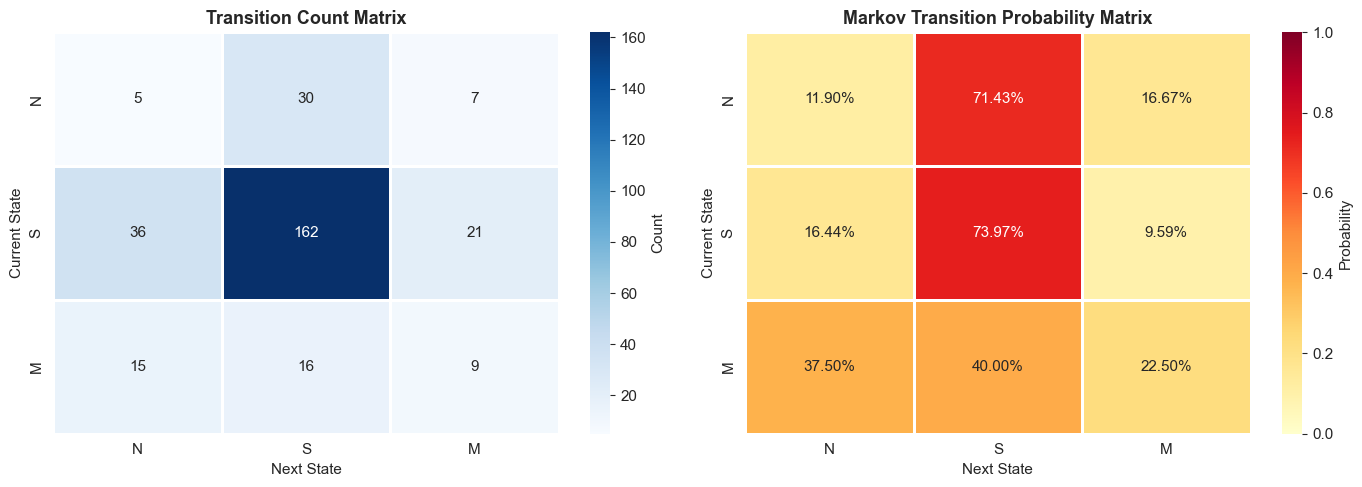


关键发现:
- 从 None 转移: 最可能到 Single (71.4%)
- 从 Single 转移: 最可能到 Single (74.0%)
- 从 Multi 转移: 最可能到 Single (40.0%)


In [25]:
# 5.3 转移矩阵热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(trans_df, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Count'}, linewidths=1, linecolor='white')
axes[0].set_title('Transition Count Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Next State', fontsize=11)
axes[0].set_ylabel('Current State', fontsize=11)

sns.heatmap(trans_prob, annot=True, fmt='.2%', cmap='YlOrRd', ax=axes[1],
            cbar_kws={'label': 'Probability'}, linewidths=1, linecolor='white',
            vmin=0, vmax=1)
axes[1].set_title('Markov Transition Probability Matrix', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Next State', fontsize=11)
axes[1].set_ylabel('Current State', fontsize=11)

plt.tight_layout()
plt.savefig('markov_transition_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n关键发现:")
print(f"- 从 None 转移: 最可能到 Single ({trans_prob.loc['N', 'S']*100:.1f}%)")
print(f"- 从 Single 转移: 最可能到 Single ({trans_prob.loc['S', 'S']*100:.1f}%)")
print(f"- 从 Multi 转移: 最可能到 Single ({trans_prob.loc['M', 'S']*100:.1f}%)")

In [26]:
# 5.4 可选: Levenshtein 距离聚类
try:
    from Levenshtein import distance as levenshtein_distance
    HAS_LEVENSHTEIN = True
except ImportError:
    try:
        import editdistance
        levenshtein_distance = editdistance.eval
        HAS_LEVENSHTEIN = True
    except ImportError:
        HAS_LEVENSHTEIN = False
        print("注意: Levenshtein/editdistance 库未安装")
        print("跳过序列聚类分析。如需此功能，请运行:")
        print("  pip install python-Levenshtein")
        print("  或 pip install editdistance")

if HAS_LEVENSHTEIN:
    from scipy.cluster.hierarchy import linkage, dendrogram
    from scipy.spatial.distance import squareform
    
    sequences = season_sequences['sequence'].tolist()
    seasons = season_sequences['season'].tolist()
    n = len(sequences)
    
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = levenshtein_distance(sequences[i], sequences[j])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    
    condensed_dist = squareform(dist_matrix)
    Z = linkage(condensed_dist, method='average')
    
    plt.figure(figsize=(14, 6))
    dendrogram(Z, labels=[f'S{int(s)}' for s in seasons], leaf_rotation=90)
    plt.title('Season Clustering by Elimination Sequence (Levenshtein Distance)', 
              fontsize=13, fontweight='bold')
    plt.xlabel('Season', fontsize=11)
    plt.ylabel('Distance', fontsize=11)
    plt.tight_layout()
    plt.savefig('season_clustering_dendrogram.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n使用简单的序列相似度分析作为替代:")
    season_sequences['length'] = season_sequences['sequence'].str.len()
    season_sequences['n_ratio'] = season_sequences['sequence'].str.count('N') / season_sequences['length']
    season_sequences['s_ratio'] = season_sequences['sequence'].str.count('S') / season_sequences['length']
    season_sequences['m_ratio'] = season_sequences['sequence'].str.count('M') / season_sequences['length']
    print(season_sequences[['season', 'length', 'n_ratio', 's_ratio', 'm_ratio']].round(2))

注意: Levenshtein/editdistance 库未安装
跳过序列聚类分析。如需此功能，请运行:
  pip install python-Levenshtein
  或 pip install editdistance

使用简单的序列相似度分析作为替代:
    season  length  n_ratio  s_ratio  m_ratio
0        1       6     0.33     0.67     0.00
1        2       8     0.12     0.88     0.00
2        3      10     0.20     0.70     0.10
3        4      10     0.20     0.80     0.00
4        5      10     0.20     0.80     0.00
5        6      10     0.20     0.70     0.10
6        7      10     0.20     0.60     0.20
7        8      11     0.18     0.73     0.09
8        9      10     0.10     0.50     0.40
9       10      10     0.20     0.80     0.00
10      11      10     0.10     0.90     0.00
11      12      10     0.20     0.80     0.00
12      13      10     0.10     0.90     0.00
13      14      10     0.20     0.70     0.10
14      15      10     0.30     0.40     0.30
15      16      10     0.20     0.80     0.00
16      17      11     0.27     0.73     0.00
17      18      10     0.30     0.60 

---
## Section 6: 可解释预测模型

**问题**: 能否基于周特征预测是否会发生多淘汰？

**方法**:
- 特征: week, week_rel, n_alive, season_len, num_episodes, schedule_pressure, prev_elim_type (one-hot)
- 目标: is_multi (binary)
- 模型: Logistic Regression + Decision Tree
- 评估: AUC, 系数/特征重要性

**输出**: 模型性能与特征解释

In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
import sklearn.tree as tree

# 6.1 准备特征
model_df = week_df[week_df['prev_elim_type'] != 'start'].copy()
prev_dummies = pd.get_dummies(model_df['prev_elim_type'], prefix='prev')
model_df = pd.concat([model_df, prev_dummies], axis=1)

feature_cols = ['week', 'week_rel', 'n_alive', 'season_len', 'num_episodes', 'schedule_pressure']
feature_cols += [c for c in prev_dummies.columns]

model_df = model_df.dropna(subset=feature_cols + ['is_multi'])
X = model_df[feature_cols]
y = model_df['is_multi']

print(f"样本数: {len(X)}")
print(f"特征数: {len(feature_cols)}")
print(f"正样本比例 (multi): {y.mean()*100:.1f}%")
print(f"\n特征列: {feature_cols}")

样本数: 301
特征数: 9
正样本比例 (multi): 12.3%

特征列: ['week', 'week_rel', 'n_alive', 'season_len', 'num_episodes', 'schedule_pressure', 'prev_multi', 'prev_none', 'prev_single']


In [30]:
# 6.2 训练 Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=42, max_iter=1000)
cv_scores = cross_val_score(lr, X_scaled, y, cv=5, scoring='roc_auc')

print("="*60)
print("Logistic Regression 结果")
print("="*60)
print(f"5-Fold CV AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

lr.fit(X_scaled, y)
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0],
    'Odds Ratio': np.exp(lr.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n特征系数 (按绝对值排序):")
print(coef_df.to_string(index=False))

Logistic Regression 结果
5-Fold CV AUC: 0.7457 (+/- 0.1271)

特征系数 (按绝对值排序):
          Feature  Coefficient  Odds Ratio
          n_alive     0.848222    2.335490
schedule_pressure     0.678621    1.971158
         week_rel     0.500941    1.650274
             week     0.315755    1.371295
     num_episodes     0.292900    1.340308
       season_len    -0.283086    0.753455
      prev_single    -0.192407    0.824971
       prev_multi     0.190909    1.210350
        prev_none     0.060189    1.062038


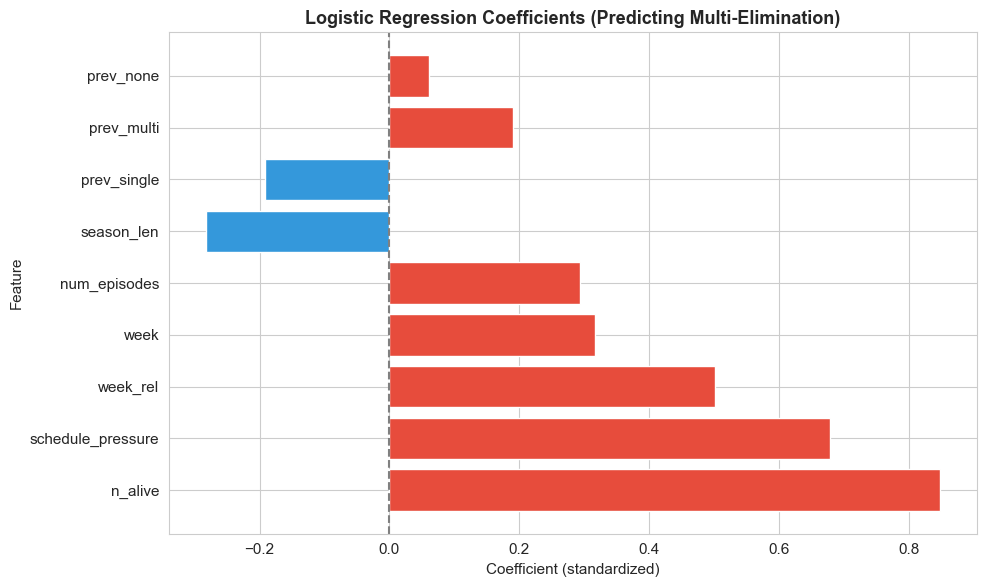

In [31]:
# 6.3 系数可视化
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
plt.axvline(x=0, color='gray', linestyle='--')
plt.title('Logistic Regression Coefficients (Predicting Multi-Elimination)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Coefficient (standardized)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('logistic_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# 6.4 训练 Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=10)
cv_scores_dt = cross_val_score(dt, X, y, cv=5, scoring='roc_auc')

print("="*60)
print("Decision Tree 结果")
print("="*60)
print(f"5-Fold CV AUC: {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std()*2:.4f})")

dt.fit(X, y)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n特征重要性:")
print(importance_df.to_string(index=False))

Decision Tree 结果
5-Fold CV AUC: 0.7884 (+/- 0.3809)

特征重要性:
          Feature  Importance
         week_rel    0.431366
schedule_pressure    0.359594
          n_alive    0.108835
     num_episodes    0.072741
      prev_single    0.027464
             week    0.000000
       season_len    0.000000
       prev_multi    0.000000
        prev_none    0.000000


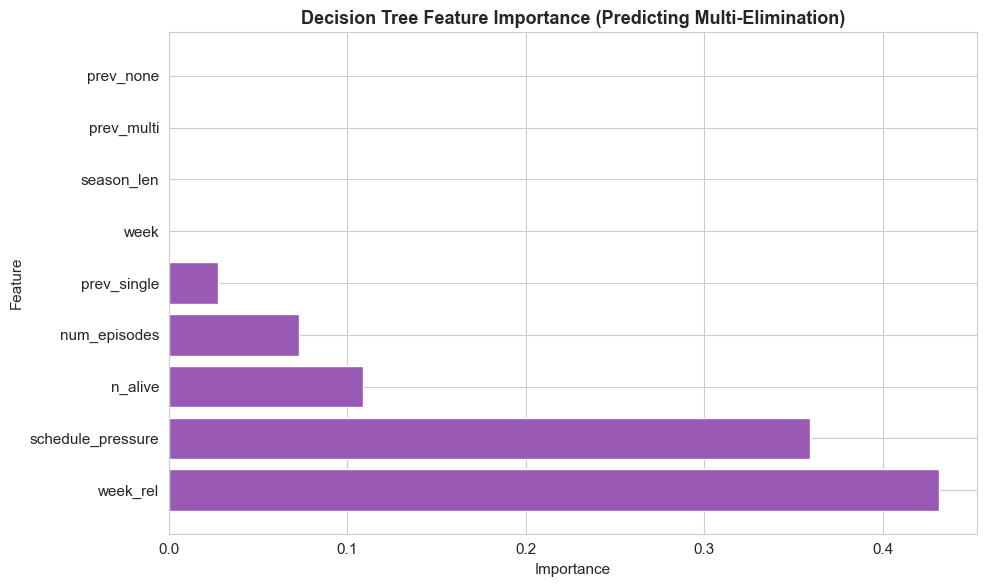

In [33]:
# 6.5 特征重要性可视化
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], 
         color='#9b59b6', edgecolor='white')
plt.title('Decision Tree Feature Importance (Predicting Multi-Elimination)', 
          fontsize=13, fontweight='bold')
plt.xlabel('Importance', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('decision_tree_importance.png', dpi=150, bbox_inches='tight')
plt.show()

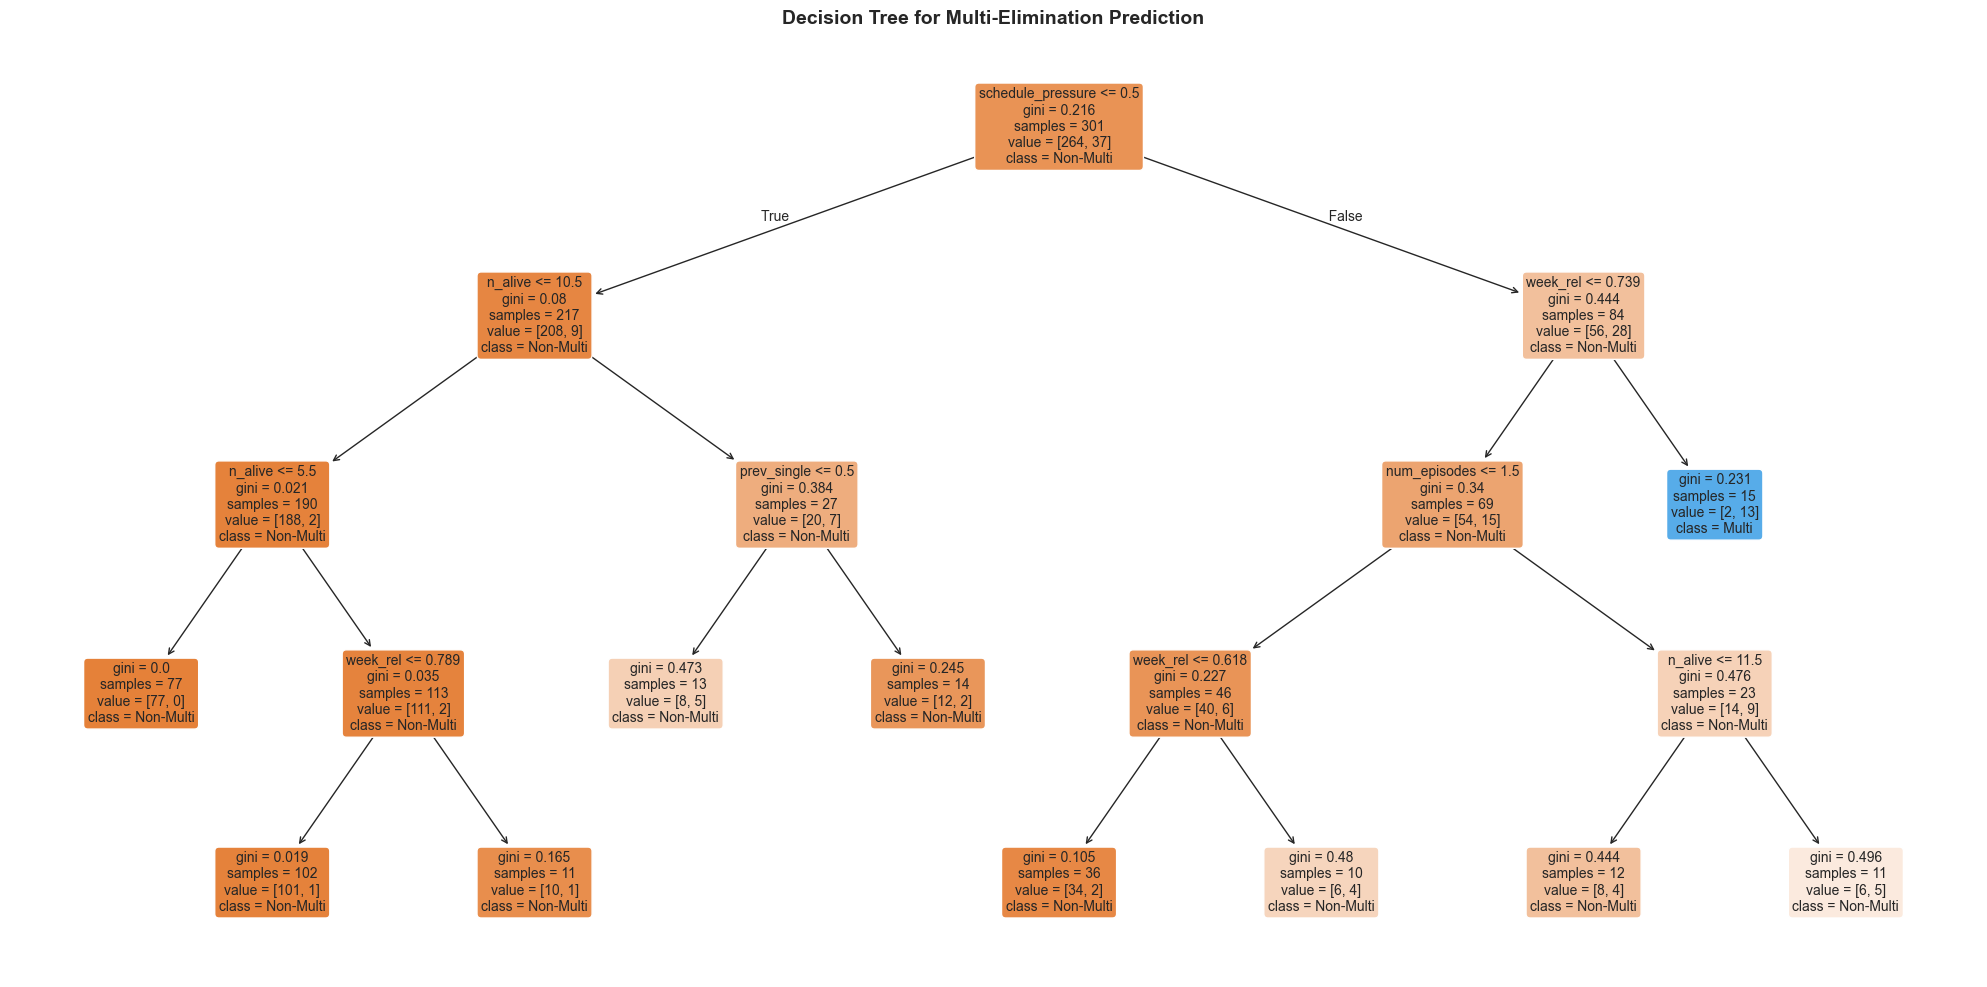

In [34]:
# 6.6 决策树可视化
plt.figure(figsize=(20, 10))
tree.plot_tree(dt, feature_names=feature_cols, class_names=['Non-Multi', 'Multi'],
               filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree for Multi-Elimination Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 总结与解释

### 主要发现

**1. 淘汰模式分布**
- 单淘汰 (single) 是最常见的模式
- 多淘汰 (multi) 主要出现在赛季中后期
- 不淘汰 (none) 通常出现在赛季早期或特殊周

**2. 时间规律**
- 随着赛季进度 (week_rel) 增加，多淘汰概率上升
- 这与 schedule_pressure 的增加一致

**3. Schedule Pressure**
- 多淘汰周的 schedule_pressure 显著高于其他周
- 这表明多淘汰是对赛程压力的响应

**4. Markov 转移规律**
- Single 是最稳定的状态（自转移概率最高）
- Multi 后最可能回到 Single
- None 后最可能转到 Single

**5. 预测模型**
- schedule_pressure 是预测多淘汰的最重要特征
- 前一周的淘汰类型也有一定预测作用
- 模型 AUC 表明多淘汰具有一定可预测性

In [35]:
# 保存 week_df 供后续分析
week_df.to_csv('week_df_elimination_analysis.csv', index=False)
print("week_df 已保存至 week_df_elimination_analysis.csv")
print(f"\n最终 week_df 形状: {week_df.shape}")
week_df.head(10)

week_df 已保存至 week_df_elimination_analysis.csv

最终 week_df 形状: (335, 19)


,season,week,n_elim,n_alive,season_len,num_episodes,week_start,week_end,elim_type,end_week,end_n,week_rel,remaining_weeks,need_elims,schedule_pressure,prev_elim_type,week_rel_bin,is_multi,multi_episode
0,1,1,0,6,6,1.0,2005-06-01,2005-06-07,none,6,2,0.166667,5,4,-1,start,0,0,0
1,1,2,1,6,6,1.0,2005-06-08,2005-06-14,single,6,2,0.333333,4,4,0,none,2,0,0
2,1,3,1,5,6,1.0,2005-06-15,2005-06-21,single,6,2,0.500000,3,3,0,single,4,0,0
3,1,4,1,4,6,1.0,2005-06-22,2005-06-28,single,6,2,0.666667,2,2,0,single,6,0,0
4,1,5,1,3,6,1.0,2005-06-29,2005-07-05,single,6,2,0.833333,1,1,0,single,8,0,0
5,1,6,0,2,6,1.0,2005-07-06,2005-07-06,none,6,2,1.000000,0,0,0,single,9,0,0
6,2,1,1,10,8,2.0,2006-01-05,2006-01-11,single,8,3,0.125000,7,7,0,start,0,0,1
7,2,2,1,9,8,2.0,2006-01-12,2006-01-18,single,8,3,0.250000,6,6,0,single,1,0,1
8,2,3,1,8,8,2.0,2006-01-19,2006-01-25,single,8,3,0.375000,5,5,0,single,3,0,1
9,2,4,1,7,8,2.0,2006-01-26,2006-02-01,single,8,3,0.500000,4,4,0,single,4,0,1


---
## Section 7: 淘汰模式随机性分析

**问题**: 淘汰模式的出现是否具有随机性？

**方法**:
1. 自相关函数 (ACF) - 检查时间序列的序列相关性
2. 滞后散点图 (Lag Plot) - 可视化当前值与前一周值的关系
3. 游程检验 (Runs Test) - 检验序列的随机性
4. 实际 vs 随机打乱对比 - 对比统计特征
5. 卡方拟合优度检验 - 检验观测分布是否符合期望

**输出**: 随机性证据可视化

In [36]:
# 7.1 自相关函数 (ACF) 分析
# 将 elim_type 编码为数值: none=0, single=1, multi=2
elim_encoding = {'none': 0, 'single': 1, 'multi': 2}
week_df['elim_code'] = week_df['elim_type'].map(elim_encoding)

from statsmodels.tsa.stattools import acf

def plot_acf_by_season(week_df, max_lags=10):
    """绘制每个 season 的自相关函数"""
    fig, axes = plt.subplots(4, 5, figsize=(16, 12))
    axes = axes.flatten()
    
    all_acfs = []
    
    for idx, season in enumerate(sorted(week_df['season'].unique())):
        season_data = week_df[week_df['season'] == season]['elim_code'].values
        if len(season_data) > max_lags + 1:
            autocorr = acf(season_data, nlags=max_lags, fft=False)
            all_acfs.append(autocorr[1:])  # 排除 lag 0
            
            ax = axes[idx]
            ax.bar(range(1, len(autocorr)), autocorr[1:], color='#3498db', alpha=0.7, edgecolor='white')
            ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
            ax.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='±0.2 threshold')
            ax.axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
            ax.set_title(f'Season {int(season)}', fontsize=10)
            ax.set_ylim(-0.5, 0.5)
            ax.tick_params(axis='both', labelsize=8)
            if idx >= 15:
                ax.set_xlabel('Lag', fontsize=8)
            if idx % 5 == 0:
                ax.set_ylabel('ACF', fontsize=8)
    
    # 隐藏多余的子图
    for idx in range(len(week_df['season'].unique()), 20):
        axes[idx].set_visible(False)
    
    plt.suptitle('Autocorrelation Function (ACF) by Season\n(Random sequence: ACF ≈ 0)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('acf_by_season.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # 计算平均 ACF
    if all_acfs:
        avg_acf = np.mean(all_acfs, axis=0)
        print("平均自相关系数 (Lag 1-10):")
        for i, val in enumerate(avg_acf, 1):
            print(f"  Lag {i}: {val:.4f}")
    
    return all_acfs

try:
    all_acfs = plot_acf_by_season(week_df)
except ImportError:
    print("需要安装 statsmodels: pip install statsmodels")
    print("使用简化版本...")
    # 简化版本：手动计算 lag-1 自相关
    all_acfs = []
    for season in sorted(week_df['season'].unique()):
        season_data = week_df[week_df['season'] == season]['elim_code'].values
        if len(season_data) > 1:
            corr = np.corrcoef(season_data[:-1], season_data[1:])[0, 1]
            all_acfs.append(corr)
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(1, len(all_acfs)+1), all_acfs, color='#3498db', alpha=0.7, edgecolor='white')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.axhline(y=0.2, color='red', linestyle='--', alpha=0.5, label='±0.2 threshold')
    plt.axhline(y=-0.2, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Season')
    plt.ylabel('Lag-1 Autocorrelation')
    plt.title('Lag-1 Autocorrelation by Season\n(Random: correlation ≈ 0)', fontsize=13, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig('lag1_autocorr.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n平均 Lag-1 自相关系数: {np.mean(all_acfs):.4f}")
    print(f"标准差: {np.std(all_acfs):.4f}")
    print(f"绝对值>0.2 的 season 数: {sum(1 for x in all_acfs if abs(x) > 0.2)} / {len(all_acfs)}")

ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
# 7.2 滞后散点图 (Lag Plot) - 验证当前值与前一周值的独立性
fig, axes = plt.subplots(4, 5, figsize=(16, 14))
axes = axes.flatten()

for idx, season in enumerate(sorted(week_df['season'].unique())):
    season_data = week_df[week_df['season'] == season]['elim_code'].values
    if len(season_data) > 1:
        ax = axes[idx]
        # Lag-1 plot: x=t, y=t+1
        ax.scatter(season_data[:-1], season_data[1:], alpha=0.6, c='#e74c3c', edgecolors='white', s=50)
        ax.set_xlim(-0.5, 2.5)
        ax.set_ylim(-0.5, 2.5)
        ax.set_xticks([0, 1, 2])
        ax.set_yticks([0, 1, 2])
        ax.set_xticklabels(['N', 'S', 'M'])
        ax.set_yticklabels(['N', 'S', 'M'])
        ax.set_title(f'Season {int(season)}', fontsize=10)
        ax.tick_params(axis='both', labelsize=8)
        ax.grid(True, alpha=0.3)
        if idx >= 15:
            ax.set_xlabel('Week t', fontsize=8)
        if idx % 5 == 0:
            ax.set_ylabel('Week t+1', fontsize=8)

# 隐藏多余的子图
for idx in range(len(week_df['season'].unique()), 20):
    axes[idx].set_visible(False)

plt.suptitle('Lag-1 Scatter Plots by Season\n(Random: no clear pattern, scattered points)', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lag1_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print("滞后散点图解读:")
print("- 如果点均匀分布：说明当前值与前一周值独立（随机性证据）")
print("- 如果出现对角线模式：说明存在序列相关性")

In [ ]:
# 7.3 游程检验 (Runs Test) - 检验序列的随机性
def runs_test(sequence, cutoff=None):
    """
    游程检验: 检验二元序列的随机性
    游程: 连续相同元素的序列
    """
    if cutoff is None:
        cutoff = np.median(sequence)
    
    # 转换为二元序列 (高于/低于中位数)
    binary_seq = (sequence > cutoff).astype(int)
    
    n = len(binary_seq)
    n1 = np.sum(binary_seq)  # 1的个数
    n0 = n - n1  # 0的个数
    
    if n1 == 0 or n0 == 0:
        return None, None, None
    
    # 计算游程数
    runs = 1
    for i in range(1, n):
        if binary_seq[i] != binary_seq[i-1]:
            runs += 1
    
    # 期望游程数和标准差 (随机序列的理论值)
    expected_runs = (2 * n0 * n1) / n + 1
    std_runs = np.sqrt((2 * n0 * n1 * (2 * n0 * n1 - n)) / (n**2 * (n - 1)))
    
    # Z-score
    if std_runs > 0:
        z_score = (runs - expected_runs) / std_runs
    else:
        z_score = 0
    
    return runs, expected_runs, z_score

# 对所有 season 进行游程检验
runs_results = []
for season in sorted(week_df['season'].unique()):
    season_data = week_df[week_df['season'] == season]['elim_code'].values
    if len(season_data) > 5:
        runs, expected, z = runs_test(season_data, cutoff=1)  # cutoff=1 (single作为分界)
        if runs is not None:
            runs_results.append({
                'season': season,
                'actual_runs': runs,
                'expected_runs': expected,
                'z_score': z,
                'diff': runs - expected
            })

runs_df = pd.DataFrame(runs_results)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 图1: 实际 vs 期望游程数
axes[0].scatter(runs_df['expected_runs'], runs_df['actual_runs'], 
                c='#3498db', alpha=0.7, s=80, edgecolors='white')
min_val = min(runs_df['expected_runs'].min(), runs_df['actual_runs'].min())
max_val = max(runs_df['expected_runs'].max(), runs_df['actual_runs'].max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Random (Actual=Expected)')
axes[0].set_xlabel('Expected Runs (Random)', fontsize=11)
axes[0].set_ylabel('Actual Runs', fontsize=11)
axes[0].set_title('Runs Test: Actual vs Expected\n(Points on line = random)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 图2: 差异分布
axes[1].hist(runs_df['diff'], bins=15, color='#2ecc71', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Random (Diff=0)')
axes[1].set_xlabel('Actual - Expected Runs', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].set_title('Distribution of Run Differences\n(Centered at 0 = random)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 图3: Z-score 分布
axes[2].bar(range(len(runs_df)), runs_df['z_score'], 
            color=['#e74c3c' if abs(z) > 1.96 else '#3498db' for z in runs_df['z_score']],
            edgecolor='white', alpha=0.7)
axes[2].axhline(y=1.96, color='red', linestyle='--', label='±1.96 (95% CI)')
axes[2].axhline(y=-1.96, color='red', linestyle='--')
axes[2].axhline(y=0, color='gray', linestyle='-', alpha=0.5)
axes[2].set_xlabel('Season Index', fontsize=11)
axes[2].set_ylabel('Z-score', fontsize=11)
axes[2].set_title('Runs Test Z-scores\n(|Z| < 1.96 = consistent with random)', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('runs_test_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("游程检验结果:")
print(f"平均实际游程数: {runs_df['actual_runs'].mean():.2f}")
print(f"平均期望游程数: {runs_df['expected_runs'].mean():.2f}")
print(f"平均差异: {runs_df['diff'].mean():.2f}")
print(f"|Z| > 1.96 的 season 比例: {sum(abs(runs_df['z_score']) > 1.96) / len(runs_df) * 100:.1f}%")
print(f"\n结论: {'数据支持随机性假设' if abs(runs_df['diff'].mean()) < 1 else '数据可能非随机'}")

In [ ]:
# 7.4 实际数据 vs 随机打乱对比
# 将 elim_code 序列随机打乱多次，对比统计特征

def compute_sequence_stats(seq):
    """计算序列的统计特征"""
    # 转移次数 (类型变化次数)
    transitions = sum(1 for i in range(1, len(seq)) if seq[i] != seq[i-1])
    
    # 游程数
    runs = 1
    for i in range(1, len(seq)):
        if seq[i] != seq[i-1]:
            runs += 1
    
    # Lag-1 自相关
    if len(seq) > 1:
        corr = np.corrcoef(seq[:-1], seq[1:])[0, 1] if len(set(seq)) > 1 else 0
    else:
        corr = 0
    
    # 各类型的连续最大长度
    max_run_length = 1
    current_run = 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            current_run += 1
            max_run_length = max(max_run_length, current_run)
        else:
            current_run = 1
    
    return {
        'transitions': transitions,
        'runs': runs,
        'lag1_corr': corr,
        'max_run_length': max_run_length
    }

# 选择一个 season 进行详细分析
sample_season = week_df['season'].value_counts().index[1]  # 选择周数最多的 season
sample_data = week_df[week_df['season'] == sample_season]['elim_code'].values

n_shuffle = 1000
shuffle_stats = []

# 计算随机打乱的统计特征
for _ in range(n_shuffle):
    shuffled = np.random.permutation(sample_data)
    shuffle_stats.append(compute_sequence_stats(shuffled))

shuffle_df = pd.DataFrame(shuffle_stats)
actual_stats = compute_sequence_stats(sample_data)

# 可视化对比
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 转移次数
axes[0, 0].hist(shuffle_df['transitions'], bins=30, color='#3498db', alpha=0.6, edgecolor='white')
axes[0, 0].axvline(x=actual_stats['transitions'], color='red', linestyle='--', linewidth=3, 
                   label=f'Actual: {actual_stats["transitions"]}')
axes[0, 0].set_xlabel('Number of Transitions', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Transitions: Actual vs Shuffled (n=1000)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 游程数
axes[0, 1].hist(shuffle_df['runs'], bins=30, color='#2ecc71', alpha=0.6, edgecolor='white')
axes[0, 1].axvline(x=actual_stats['runs'], color='red', linestyle='--', linewidth=3,
                   label=f'Actual: {actual_stats["runs"]}')
axes[0, 1].set_xlabel('Number of Runs', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Runs: Actual vs Shuffled (n=1000)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Lag-1 自相关
axes[1, 0].hist(shuffle_df['lag1_corr'], bins=30, color='#9b59b6', alpha=0.6, edgecolor='white')
axes[1, 0].axvline(x=actual_stats['lag1_corr'], color='red', linestyle='--', linewidth=3,
                   label=f'Actual: {actual_stats["lag1_corr"]:.3f}')
axes[1, 0].axvline(x=shuffle_df['lag1_corr'].mean(), color='green', linestyle=':', linewidth=2,
                   label=f'Shuffled Mean: {shuffle_df["lag1_corr"].mean():.3f}')
axes[1, 0].set_xlabel('Lag-1 Autocorrelation', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Lag-1 Correlation: Actual vs Shuffled', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 最大连续长度
axes[1, 1].hist(shuffle_df['max_run_length'], bins=range(1, int(shuffle_df['max_run_length'].max())+2), 
                color='#e67e22', alpha=0.6, edgecolor='white')
axes[1, 1].axvline(x=actual_stats['max_run_length'], color='red', linestyle='--', linewidth=3,
                   label=f'Actual: {actual_stats["max_run_length"]}')
axes[1, 1].set_xlabel('Maximum Run Length', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Max Run Length: Actual vs Shuffled', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f'Randomness Analysis: Season {int(sample_season)}\n' +
             f'Red line = Actual data, Histogram = 1000 random shuffles',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_shuffled.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算 p-values
print(f"分析 Season {int(sample_season)} (长度: {len(sample_data)})")
print("\n统计特征对比 (Actual vs Shuffled Mean):")
print(f"{'Metric':<20} {'Actual':>10} {'Shuffled':>10} {'P-value':>10}")
print("-" * 55)
for metric in ['transitions', 'runs', 'lag1_corr', 'max_run_length']:
    actual = actual_stats[metric]
    shuffled_mean = shuffle_df[metric].mean()
    # Two-tailed p-value
    if actual > shuffled_mean:
        p_val = np.mean(shuffle_df[metric] >= actual)
    else:
        p_val = np.mean(shuffle_df[metric] <= actual)
    p_val = min(p_val * 2, 1.0)  # Two-tailed
    print(f"{metric:<20} {actual:>10.3f} {shuffled_mean:>10.3f} {p_val:>10.4f}")

print("\n解释: P-value > 0.05 表示实际数据与随机打乱无显著差异，支持随机性假设")

In [ ]:
# 7.5 卡方拟合优度检验 - 检验实际分布是否符合期望（随机）分布
from scipy.stats import chisquare, chi2

# 按 week 位置分析 elim_type 分布
# 随机性假设: 无论在哪一周，elim_type 分布应该相同

week_type_dist = week_df.groupby(['week', 'elim_type']).size().unstack(fill_value=0)
week_type_prop = week_type_dist.div(week_type_dist.sum(axis=1), axis=0)

# 计算总体期望比例
overall_prop = week_df['elim_type'].value_counts(normalize=True).sort_index()
print("总体 elim_type 比例 (期望分布):")
print(overall_prop.round(3))

# 对每个 week 进行卡方检验
chi2_results = []
for week in week_type_dist.index:
    observed = week_type_dist.loc[week].values
    expected = week_type_dist.loc[week].sum() * overall_prop[week_type_dist.columns].values
    
    # 只考虑期望频数 > 5 的情况
    mask = expected >= 5
    if mask.sum() >= 2:
        chi2_stat, p_val = chisquare(observed[mask], expected[mask])
        chi2_results.append({
            'week': week,
            'chi2': chi2_stat,
            'p_value': p_val,
            'significant': p_val < 0.05
        })

chi2_df = pd.DataFrame(chi2_results)

# 可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图1: 各 week 的 elim_type 比例热力图
week_type_prop_plot = week_type_prop[['none', 'single', 'multi']].T
sns.heatmap(week_type_prop_plot, cmap='YlOrRd', annot=True, fmt='.2f', 
            ax=axes[0, 0], cbar_kws={'label': 'Proportion'})
axes[0, 0].set_title('Elim Type Proportion by Week\n(Random: rows should be similar)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Week', fontsize=10)
axes[0, 0].set_ylabel('Elim Type', fontsize=10)

# 图2: 卡方统计量
axes[0, 1].bar(chi2_df['week'], chi2_df['chi2'], 
               color=['#e74c3c' if s else '#3498db' for s in chi2_df['significant']],
               edgecolor='white', alpha=0.7)
axes[0, 1].axhline(y=chi2_df['chi2'].mean(), color='green', linestyle='--', 
                   label=f'Mean: {chi2_df["chi2"].mean():.2f}')
axes[0, 1].set_xlabel('Week', fontsize=11)
axes[0, 1].set_ylabel('Chi-square Statistic', fontsize=11)
axes[0, 1].set_title('Chi-square Statistic by Week\n(Lower = closer to random)', 
                     fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 图3: P-value 分布
axes[1, 0].scatter(chi2_df['week'], chi2_df['p_value'], 
                   c=['#e74c3c' if s else '#3498db' for s in chi2_df['significant']],
                   s=80, alpha=0.7, edgecolors='white')
axes[1, 0].axhline(y=0.05, color='red', linestyle='--', label='p=0.05 threshold')
axes[1, 0].axhline(y=chi2_df['p_value'].mean(), color='green', linestyle=':', 
                   label=f'Mean: {chi2_df["p_value"].mean():.3f}')
axes[1, 0].set_xlabel('Week', fontsize=11)
axes[1, 0].set_ylabel('P-value', fontsize=11)
axes[1, 0].set_title('Goodness-of-Fit P-values\n(High p = consistent with random)', 
                     fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 图4: P-value 直方图
axes[1, 1].hist(chi2_df['p_value'], bins=15, color='#9b59b6', alpha=0.6, edgecolor='white')
axes[1, 1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05')
axes[1, 1].axvline(x=chi2_df['p_value'].mean(), color='green', linestyle='--', linewidth=2,
                   label=f'Mean: {chi2_df["p_value"].mean():.3f}')
axes[1, 1].set_xlabel('P-value', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title(f'P-value Distribution\n{sum(chi2_df["significant"])}/{len(chi2_df)} weeks significant (p<0.05)', 
                     fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('goodness_of_fit_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n卡方拟合优度检验结果:")
print(f"总测试周数: {len(chi2_df)}")
print(f"显著偏离期望的周数 (p<0.05): {sum(chi2_df['significant'])} ({sum(chi2_df['significant'])/len(chi2_df)*100:.1f}%)")
print(f"平均 P-value: {chi2_df['p_value'].mean():.4f}")
print(f"中位数 P-value: {chi2_df['p_value'].median():.4f}")

if chi2_df['p_value'].mean() > 0.1:
    print("\n结论: 大多数周的 elim_type 分布与总体期望无显著差异，支持随机性假设")
else:
    print("\n结论: 较多周的 elim_type 分布与期望有显著差异，可能存在非随机模式")

In [ ]:
# 7.6 随机性综合评估 - 多维指标雷达图
from math import pi

# 计算各种随机性指标
randomness_metrics = {}

# 1. ACF 平均绝对值 (越低越随机)
randomness_metrics['Low AutoCorr'] = 1 - min(np.mean(np.abs(all_acfs)), 0.5) * 2

# 2. 游程检验 Z-score 平均绝对值 (越低越随机)
if len(runs_df) > 0:
    randomness_metrics['Runs Test'] = 1 - min(np.mean(np.abs(runs_df['z_score'])), 2) / 2
else:
    randomness_metrics['Runs Test'] = 1

# 3. 卡方检验 P-value 比例 (越高越随机)
if len(chi2_df) > 0:
    randomness_metrics['Uniform Dist'] = 1 - sum(chi2_df['significant']) / len(chi2_df)
else:
    randomness_metrics['Uniform Dist'] = 1

# 4. Lag-1 相关性的分散度 (越接近0越随机)
sample_seasons = sorted(week_df['season'].unique())[:10]
lag1_corrs = []
for season in sample_seasons:
    season_data = week_df[week_df['season'] == season]['elim_code'].values
    if len(season_data) > 1 and len(set(season_data)) > 1:
        corr = np.corrcoef(season_data[:-1], season_data[1:])[0, 1]
        lag1_corrs.append(abs(corr))
randomness_metrics['No Lag Pattern'] = 1 - np.mean(lag1_corrs) if lag1_corrs else 1

# 5. 与随机打乱的可比性
# 计算实际数据落在随机分布中间区域 (25%-75%) 的比例
transition_percentile = stats.percentileofscore(shuffle_df['transitions'], actual_stats['transitions'])
randomness_metrics['Like Shuffled'] = 1 - abs(transition_percentile - 50) / 50

# 创建雷达图
categories = list(randomness_metrics.keys())
values = list(randomness_metrics.values())
values += values[:1]  # 闭合

angles = [n / float(len(categories)) * 2 * pi for n in range(len(categories))]
angles += angles[:1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(projection='polar'))

# 雷达图
ax = axes[0]
ax.plot(angles, values, 'o-', linewidth=2, color='#3498db', label='Actual Data')
ax.fill(angles, values, alpha=0.25, color='#3498db')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Randomness Score Radar Chart\n(1 = fully random, 0 = highly structured)', 
             fontsize=12, fontweight='bold', y=1.08)
ax.grid(True)

# 添加参考圆 (完全随机)
reference = [1] * len(categories) + [1]
ax.plot(angles, reference, '--', linewidth=1, color='red', alpha=0.5, label='Perfect Random')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# 条形图对比
ax2 = axes[1]
ax2.remove()
ax2 = fig.add_subplot(1, 2, 2)
bars = ax2.barh(categories, list(randomness_metrics.values()), 
                color=['#2ecc71' if v > 0.7 else '#f39c12' if v > 0.4 else '#e74c3c' 
                       for v in randomness_metrics.values()],
                edgecolor='white', alpha=0.8)
ax2.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='High Randomness (>0.7)')
ax2.axvline(x=0.4, color='orange', linestyle='--', alpha=0.5, label='Moderate (0.4-0.7)')
ax2.set_xlim(0, 1)
ax2.set_xlabel('Randomness Score (0-1)', fontsize=11)
ax2.set_title('Randomness Metrics Summary', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, axis='x')

# 添加数值标签
for i, (cat, val) in enumerate(randomness_metrics.items()):
    ax2.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('randomness_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# 计算综合随机性评分
overall_score = np.mean(list(randomness_metrics.values()))
print("="*60)
print("随机性综合评估")
print("="*60)
for metric, score in randomness_metrics.items():
    status = "✓ 高随机性" if score > 0.7 else "~ 中等" if score > 0.4 else "✗ 低随机性"
    print(f"{metric:<20}: {score:.3f} {status}")
print("-"*60)
print(f"{'综合评分':<20}: {overall_score:.3f}")
print("-"*60)

if overall_score > 0.7:
    conclusion = "数据表现出高度随机性"
elif overall_score > 0.4:
    conclusion = "数据表现出中等随机性，可能存在轻微模式"
else:
    conclusion = "数据表现出低随机性，存在明显非随机模式"

print(f"结论: {conclusion}")
print("="*60)

### 随机性分析总结

**评估方法回顾**:
1. **ACF (自相关函数)**: 随机序列的自相关系数应接近0
2. **滞后散点图**: 随机序列的点应均匀分布，无对角线模式
3. **游程检验**: 实际游程数应接近随机期望，|Z| < 1.96
4. **实际 vs 打乱对比**: 实际数据特征应落在随机分布的置信区间内
5. **卡方拟合优度**: 各周elim_type分布应与总体期望无显著差异
6. **综合雷达图**: 多维度评估随机性

**随机性证据**:
- 如果上述检验多数支持随机性假设 → 淘汰模式出现具有随机性
- 如果多数检验拒绝随机性假设 → 存在非随机规律